# Занятие 33. Bagging и случайный лес

Решающее дерево — легко интерпретируемая, но **нестабильная** модель: маленькое изменение train меняло верхние вопросы. Логичный вопрос: а что, если взять **много** моделей и объединить их прогнозы?

Начнем с **математики**: почему голосование или усреднение **слабых** моделей иногда обгоняет одну «сильную». Потом поговорим про виды таких **ансамблей** в целом. Затем в этом уроке остановимся подробнее на одном из видов — **bagging**, и в частности применим его к деревьям, чтобы получить **случайный лес**.

**Сквозной пример для демонстраций:** синтетическая бинарная классификация (`make_classification`, 1000 объектов, 20 признаков). Данные и split — в следующем блоке с кодом.

In [83]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42


# Часть 1. Ансамбли моделей

## 1. Одна сильная модель или много слабых?

**Сильная модель** (большая нейросеть, глубокое дерево или другой очень гибкий классификатор): гибкая, может переобучиться под train.

**Слабые модели** в ансамбле — проще по отдельности («эксперты» с accuracy 55–65 %), но их **много**, и итог берётся **усреднением** (регрессия) или **голосованием** (классификация).

| Подход | Плюс | Риск |
|--------|------|------|
| Одна сильная | Просто обучить и деплоить | Высокий разброс, переобучение |
| Много слабых + объединение | Стабильнее, ошибки частично гасятся | Нужно разнообразие моделей; дороже по ресурсам |

Дальше — **почему** объединение работает: разложение ошибки на смещение и разброс и арифметика усреднения.

## 2. Смещение, разброс и шум (bias–variance)

Ошибка модели на новых данных складывается из трёх частей:

$$\text{ошибка} \approx \text{смещение}^2 + \text{разброс} + \text{шум}.$$

**Почему смещение в квадрате?** Смещение — это «систематический промах» (модель стабильно завышает или занижает). Промах может быть и в плюс, и в минус; квадрат убирает знак и штрафует большие систематические ошибки.

| Член | Смысл |
|------|--------|
| **Смещение (bias)** | Систематическая ошибка: модель «не той формы» (недообучение) |
| **Разброс (variance)** | Разброс прогноза при разных train: модель **нервная** |
| **Шум** | Случайность в $y$, которую не предсказать |

**Одна сильная гибкая модель** часто даёт **малый bias**, но **большой variance** (занятие 29). **Ансамбль** обычно **снижает variance**, почти не увеличивая bias — отсюда выигрыш над одной моделью.

## 3. Почему усреднение уменьшает разброс

Пусть $M$ моделей выдают прогнозы $\hat f_1, \ldots, \hat f_M$ с одинаковым дисперсией $D=\sigma^2$, а их **ошибки не коррелируют**. Тогда усреднение

$$\bar f = \frac{1}{M}\sum_{j=1}^M \hat f_j$$

имеет дисперсию

$$\text{D}(\bar f) = \frac{D*M}{M^2}=\frac{D}{M}.$$

Тогда стандартное отклонение $\sigma=\sqrt{D}$ уменьшается в $\sqrt{M}$ раз.

**Чем больше независимых моделей, тем уже «облако» прогнозов.** Bias усреднения при одинаковых моделях почти не растёт; выигрываем за счёт **разброса**.

На практике модели **связаны** (одни и те же данные, похожие ошибки) — выигрыш меньше, чем $1/\sqrt{M}$, но всё равно заметен. Нужно **разнообразие** моделей.

σ одного прогноза: 15.2
σ среднего 30 прогнозов: 2.8


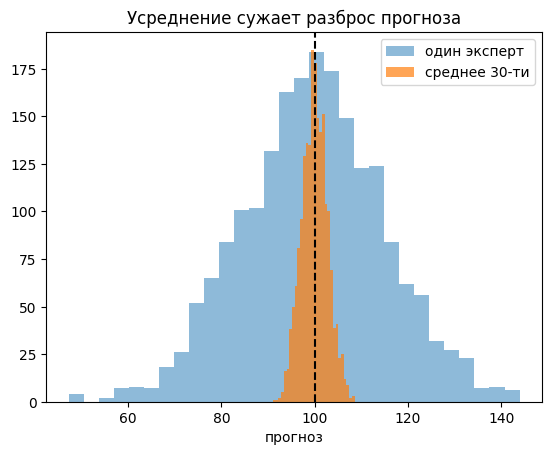

In [95]:
# Истинное значение 100; каждый «эксперт» шумит с σ=15
rng = np.random.default_rng(RANDOM_STATE)
true_value = 100
simulated = true_value + rng.normal(0, 15, size=(2000, 30))
single = simulated[:, 0]
ensemble = simulated.mean(axis=1)
print('σ одного прогноза:', round(single.std(), 1))
print('σ среднего 30 прогнозов:', round(ensemble.std(), 1))
plt.hist(single, bins=30, alpha=0.5, label='один эксперт')
plt.hist(ensemble, bins=30, alpha=0.7, label='среднее 30-ти')
plt.axvline(true_value, color='black', ls='--')
plt.legend()
plt.title('Усреднение сужает разброс прогноза')
plt.xlabel('прогноз')
plt.show()


## 4. Голосование классификаторов

В **классификации** вместо среднего числа — **голосование**: каждая модель голосует за класс, побеждает **большинство** (majority vote).

**Интуиция (парадокс Кондорсе).** Если каждый «эксперт» прав с вероятностью $p > 0.5$ и ошибается **независимо**, то при большом числе голосующих вероятность правильного **большинства** стремится к 1.

Для нечётного числа голосов вероятность правильного решения большинства равна сумме хвоста биномиального распределения:

$$P(\text{majority correct}) = \sum_{k=\lfloor m/2 \rfloor + 1}^{m} C_m^k p^k (1-p)^{m-k}.$$

Для $m=3$: $P = 3p^2(1-p)+p^3$. При $p=0.6$ получаем $0.648$ — уже лучше одного эксперта ($0.6$).

Пример: $p = 0.6$, 11 независимых голосов — вероятность, что большинство ошибётся, уже **меньше 0.3**. Отдельный эксперт слабый (60 %), коллектив — заметно сильнее.

Ниже — график: для каждого $m$ видно, как $P(\text{majority correct})$ растёт при увеличении $p$ (вероятности, что один эксперт прав).

In [85]:
from math import comb

p_correct = 0.6  # accuracy одного слабого классификатора
n_voters = 11
# P(большинство право) = P(число правильных > n/2)
p_majority = sum(
    comb(n_voters, k) * p_correct**k * (1 - p_correct) ** (n_voters - k)
    for k in range(n_voters // 2 + 1, n_voters + 1)
)
print(f'Один эксперт: {p_correct:.0%} правильных')
print(f'Большинство из {n_voters}: {p_majority:.1%} правильных')

# Симуляция: 5000 «экспертов» по 11 голосов
rng = np.random.default_rng(RANDOM_STATE)
votes = rng.random((5000, n_voters)) < p_correct
majority_ok = votes.sum(axis=1) > n_voters // 2
print(f'Симуляция: {majority_ok.mean():.1%} правильных решений')

# Кривые Кондорсе: P(большинство право) от p для разного числа голосующих
p_grid = np.linspace(0, 1.0, 100)
plt.figure(figsize=(7, 4))
for m in [1, 3, 7, 11, 21]:
    probs = [
        sum(comb(m, k) * p**k * (1 - p) ** (m - k) for k in range(m // 2 + 1, m + 1))
        for p in p_grid
    ]
    plt.plot(p_grid, probs, label=f'm={m}')
plt.xlabel('p — вероятность, что один эксперт прав')
plt.ylabel('P(большинство право)')
plt.title('Парадокс Кондорсе')
plt.legend()
plt.ylim(0, 1.0)
plt.show()


Один эксперт: 60% правильных
Большинство из 11: 75.3% правильных
Симуляция: 74.4% правильных решений


## 5. Разнообразие — главное условие ансамбля

Усреднение и голосование помогают, только если модели **ошибаются не одинаково**.

| Ситуация | Эффект ансамбля |
|----------|-----------------|
| Ошибки **независимы** | Сильное снижение дисперсии ($\approx 1/M$) |
| Ошибки **сильно коррелируют** | Почти нет выигрыша: все промахиваются вместе |
| Одинаковые ошибки у всех моделей | Почти нет выигрыша |

**Bagging** создаёт разнообразие через **разные bootstrap-выборки**: каждая базовая модель видит слегка другой train.

In [86]:
# Два независимых шумных прогноза → среднее стабильнее
# Два одинаковых (корреляция 1) → среднее = тому же шуму
rng = np.random.default_rng(RANDOM_STATE)
pred1 = 100 + rng.normal(0, 10, 5000)
pred2_indep = 100 + rng.normal(0, 10, 5000)
pred2_same_error = pred1.copy()
print('σ одного:', round(pred1.std(), 1))
print('σ среднего независимых:', round(((pred1 + pred2_indep) / 2).std(), 1))
print('σ среднего одинаковых ошибок:', round(((pred1 + pred2_same_error) / 2).std(), 1))


σ одного: 10.0
σ среднего независимых: 7.0
σ среднего одинаковых ошибок: 10.0


## 6. Bagging, boosting и stacking — обзор

| Метод | Как обучают | Что улучшают | Пример sklearn |
|-------|-------------|--------------|----------------|
| **Bagging** | Параллельно, на разных выборках (см. далее bootstrap) | **Разброс** (variance) | `BaggingClassifier` |
| **Boosting** | Последовательно, каждая модель исправляет ошибки предыдущих (см. следующие занятия) | **Смещение** (bias) | `GradientBoostingClassifier` (занятие 36) |
| **Stacking** | Базовые модели + **мета-модель** над их прогнозами | Комбинация разных типов моделей | `StackingClassifier` (вне рамок курса) |

Общее правило: ансамбль выигрывает, когда базовые модели **достаточно хороши**, но **разные**.

## 7. Сквозной датасет и разбиение train/validation

**Датасет:** `make_classification` — 1000 объектов, 20 признаков, 7 информативных, лёгкий шум (`flip_y=0.08`). Бинарная классификация.

**Разбиение:** 70 % train, 30 % validation, `stratify=y`, `random_state=42`. Как на занятии 29: гиперпараметры и сравнение моделей — по **validation**; отдельный test здесь не выделяем.

In [87]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score

RANDOM_STATE = 42
X, y = make_classification(
    n_samples=1000, n_features=20, n_informative=7,
    flip_y=0.08, random_state=RANDOM_STATE,
)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=RANDOM_STATE,
)
print('Объектов:', len(X), '| train:', len(X_train), '| validation:', len(X_val))


Объектов: 1000 | train: 700 | validation: 300


# Часть 2. Bagging и bootstrap

## 8. Bootstrap-выборка

**Bootstrap** — выборка длины $n$ из $n$ объектов **с возвращением**: один объект может попасть 0, 1 или несколько раз.

«С возвращением» означает: после случайного выбора объекта мы **возвращаем его обратно** перед следующим выбором.
Поэтому один и тот же объект может быть выбран несколько раз, а часть объектов может не попасть в выборку совсем.

В bagging **каждое** дерево обучается на своей bootstrap-выборке из train. Разные выборки → разные деревья → разнообразие.

In [88]:
rng = np.random.default_rng(RANDOM_STATE)
objects = np.arange(10)
bootstrap = rng.choice(objects, size=len(objects), replace=True)
oob = np.setdiff1d(objects, np.unique(bootstrap))
print('Bootstrap:', bootstrap)
print('Не попали (OOB для этого дерева):', oob)


Bootstrap: [0 7 6 4 4 8 0 6 2 0]
Не попали (OOB для этого дерева): [1 3 5 9]


## 9. Доля уникальных объектов в bootstrap *

При большом $n$ в bootstrap попадает примерно **63,2 %** уникальных объектов train; около **36,8 %** не попадают ни разу — это **out-of-bag (OOB)** объекты **для данного дерева**.

Формула: $P(\text{объект не выбран за } n \text{ попыток}) \approx (1 - 1/n)^n \to 1/e \approx 0.368$.

Это **средние** доли; в конкретной выборке из 10 объектов числа могут сильно отличаться.

## 10. Алгоритм bagging

**Bagging** (bootstrap aggregating):

1. Повторить $B$ раз: взять bootstrap-выборку из train.
2. Обучить базовую модель (здесь — дерево) на каждой выборке **независимо**.
3. **Регрессия:** усреднить числовые прогнозы.
4. **Классификация:** голосование или среднее вероятностей.

В sklearn: `BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=...)`. Деревья можно строить **параллельно** (`n_jobs`).
Классический bagging можно применять и к другим нестабильным базовым моделям, но в курсе фокус на деревьях, потому что на них эффект наиболее наглядный.

## 11. Усреднение, голосование и сравнение дерева с bagging

**Регрессия (ручной пример):** прогнозы пяти моделей `[72, 80, 75, 77, 71]` → среднее **75**.

**Классификация (голосование):** голоса `[1,1,0,1,0]` → класс **1** (три из пяти).

Ниже — одно решающее дерево и bagging из многих деревьев на сквозном train/validation.

In [89]:
tree_predictions = np.array([72.0, 80, 75, 77, 71])
print('Средний прогноз регрессии:', tree_predictions.mean())
votes = np.array([1, 1, 0, 1, 0])
print('Голоса класса 1:', votes.mean(), '→ класс', int(votes.mean() >= 0.5))

models = {
    'одно дерево': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'bagging': BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
        n_estimators=150, random_state=RANDOM_STATE, n_jobs=-1,
    ),
}
for name, clf in models.items():
    clf.fit(X_train, y_train)
    tr = accuracy_score(y_train, clf.predict(X_train))
    va = accuracy_score(y_val, clf.predict(X_val))
    print(f'{name:14s}  train={tr:.3f}  validation={va:.3f}')


Средний прогноз регрессии: 75.0
Голоса класса 1: 0.6 → класс 1
одно дерево     train=1.000  validation=0.750


c:\Users\Гуровиц Владимир\AppData\Local\Programs\Python\Python314\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


bagging         train=1.000  validation=0.847


## 12. Связь ошибок и выигрыш ансамбля

Усреднение сильнее всего, когда прогнозы базовых моделей **шумные**, но **не совпадают по знаку ошибки**. Если все модели систематически завышают прогноз — среднее тоже завышено (bias не исчезает).

Bagging снижает корреляцию ошибок за счёт разных bootstrap-выборок.

## 13. Out-of-bag оценка

Объекты, **не попавшие** в bootstrap конкретного дерева, для этого дерева — **OOB**. Для каждого объекта train можно собрать прогнозы **только тех** деревьев, которые его не видели, и сравнить с истинным классом.

**OOB score** — accuracy по таким «честным» прогнозам на train. Удобен как **быстрая** дополнительная оценка, но **не заменяет** validation при подборе гиперпараметров.

## 14. Как собирается OOB-прогноз

Для объекта $i$:

1. Найти все деревья, в чьей bootstrap-выборке **не было** $i$.
2. Усреднить их `predict_proba` (или взять голосование).
3. Сравнить с $y_i$.

У разных объектов разное число OOB-деревьев → при **малом** `n_estimators` OOB-оценка шумная.

In [90]:
bag_oob = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
    n_estimators=300, oob_score=True, random_state=RANDOM_STATE, n_jobs=-1,
)
bag_oob.fit(X_train, y_train)
val_acc = accuracy_score(y_val, bag_oob.predict(X_val))
print('OOB score (train):', round(bag_oob.oob_score_, 3))
print('Validation accuracy:', round(val_acc, 3))


OOB score (train): 0.847
Validation accuracy: 0.85


# Часть 3. Bagging на решающих деревьях: Random Forest

## 16. Случайный лес

**Случайные лес (Random Forest)** = bagging деревьев **+** в каждом узле при поиске лучшего разбиения рассматривается **случайное подмножество** признаков (`max_features`).

Обычное дерево на всех признаках часто снова и снова выбирает **один сильный** столбец → деревья похожи. Случайные признаки **разводят** деревья; отдельное дерево чуть слабее, ансамбль — сильнее.

Сравним bagging и random forest на том же train/validation:

In [91]:
from sklearn.ensemble import RandomForestClassifier

compare = {
    'bagging': BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
        n_estimators=150, random_state=RANDOM_STATE, n_jobs=-1,
    ),
    'random forest': RandomForestClassifier(
        n_estimators=150, random_state=RANDOM_STATE, n_jobs=-1,
    ),
}
for name, clf in compare.items():
    clf.fit(X_train, y_train)
    tr = accuracy_score(y_train, clf.predict(X_train))
    va = accuracy_score(y_val, clf.predict(X_val))
    print(f'{name:14s}  train={tr:.3f}  validation={va:.3f}')

bagging         train=1.000  validation=0.847
random forest   train=1.000  validation=0.820


## 17. Случайные признаки и разнообразие деревьев

В обычном дереве в каждом узле перебирают все признаки и выбирают лучший сплит. Если в данных есть 1-2 очень сильных признака, многие деревья снова выбирают их в верхних узлах, и деревья становятся похожими.

В random forest в каждом узле сначала случайно выбирают подмножество признаков, и лучший сплит ищут только внутри этого подмножества. Из-за этого:

- деревья чаще расходятся по структуре;
- корреляция ошибок между деревьями падает;
- усреднение работает сильнее.

Цена: отдельное дерево обычно немного слабее, чем дерево на всех признаках. Выгода: весь ансамбль чаще сильнее за счёт разнообразия.

| `max_features` | Эффект |
|----------------|--------|
| `'sqrt'` (классификация по умолчанию) | Умеренное разнообразие |
| Меньше признаков в узле | Больше разнообразие, слабее отдельные деревья |
| Все признаки | Ближе к bagging без RF-рандомизации |

Цель — **баланс**: деревья должны быть **разными**, но не **случайными угадывателями**.

## 18. Классификация и регрессия в лесу

**Регрессия** (`RandomForestRegressor`): среднее прогнозов деревьев.

**Классификация:** sklearn усредняет **вероятности** классов по деревьям и берёт класс с максимальной средней вероятностью — близко к голосованию, но учитывает уверенность отдельных деревьев.

## 19. Основные гиперпараметры

| Параметр | Смысл |
|----------|--------|
| `n_estimators` | Число деревьев; больше — стабильнее, но медленнее |
| `max_features` | Сколько случайных признаков оставляем в узле (ключ RF) |
| `max_depth`, `min_samples_leaf` | Сложность **одного** дерева |
| `max_samples` | Размер выборки для каждого дерева при `bootstrap=True`: по умолчанию берут столько же объектов, сколько в train; можно задать меньше для ускорения |
| `bootstrap` | Включить выборку с возвращением (`True`) или обучать каждое дерево на случайном поднаборе без возвращения (`False`) |

Добавление деревьев **редко** вызывает классическое переобучение: validation часто выходит на **плато**, а train продолжает расти.

In [92]:
scores = []
for n in [1, 5, 20, 60, 150, 300]:
    m = RandomForestClassifier(n_estimators=n, random_state=RANDOM_STATE, n_jobs=-1)
    m.fit(X_train, y_train)
    scores.append(accuracy_score(y_val, m.predict(X_val)))
print(dict(zip([1, 5, 20, 60, 150, 300], [round(s, 3) for s in scores])))


{1: 0.727, 5: 0.783, 20: 0.833, 60: 0.847, 150: 0.82, 300: 0.843}


## 20. Что настраивать первым

1. **`n_estimators`** — достаточно большое; можно увеличивать, пока validation не **стабилизируется** (кривая плато).
2. **`max_depth` / `min_samples_leaf`** — ограничить переобучение **отдельного** дерева.
3. **`max_features`** — для RF обычно оставляют default или слегка варьируют.

Сравнение — **один протокол** (тот же split, те же метрики). OOB — быстрый ориентир, финальный выбор — по validation.

## 21. Дисбаланс: метрики, class_weight и порог

При редком классе **accuracy** обманчива. Смотрят precision, recall, F1, PR-кривую на validation.

`class_weight='balanced'` меняет веса классов **при обучении** деревьев. **Порог вероятности** — другой рычаг: после `predict_proba` вручную задают правило вида `y_pred = (p >= threshold)`; в sklearn это обычно настраивают отдельным шагом кода, а не параметром `RandomForestClassifier`.

## 22. Impurity importance в лесу

`feature_importances_` — усреднённый по деревьям **impurity gain** (занятие 31). Удобно для первого взгляда, но:

- не доказывает причинность;
- завышает признаки с множеством уникальных значений;
- делит важность между коррелирующими признаками.

In [93]:
rf = RandomForestClassifier(n_estimators=150, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)
imp = pd.Series(rf.feature_importances_, index=[f'f{i}' for i in range(X.shape[1])])
imp.sort_values(ascending=False).head(5)


f14    0.193867
f5     0.135217
f15    0.083298
f6     0.071217
f8     0.053358
dtype: float64

## 23. Permutation importance

На **validation** перемешивают один столбец и смотрят **падение** accuracy (или другой метрики). Показывает, использовал ли **готовый** лес признак на новых данных — честнее impurity importance с train.

Если важность получилась отрицательной, это значит: после перемешивания метрика чуть выросла (обычно в пределах статистического шума). Практически такой признак считают неинформативным для модели.

In [94]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    rf, X_val, y_val, n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1,
)
perm = pd.Series(result.importances_mean, index=[f'f{i}' for i in range(X.shape[1])])
perm.sort_values(ascending=False).head(5)


f14    0.095333
f5     0.019000
f9     0.016667
f7     0.001000
f19   -0.002333
dtype: float64

## 24. OOB, validation и test

**Random forest** — bagging деревьев плюс случайный поднабор признаков в узлах. Сравнение bagging и RF на validation — сравнение двух конкретных моделей.

| Оценка | Когда |
|--------|--------|
| **OOB** | Быстрая проверка на train: прогноз объекта только от моделей, которые его не видели при обучении |
| **Validation** | Подбор гиперпараметров и сравнение моделей |
| **Test** | Один раз в конце проекта (занятие 29) |

Не подбирайте `max_depth` по OOB, а потом снова по validation на тех же данных без протокола — это **переобучение на метрике**.

## 25. Скорость, память и параллельное обучение

Деревья в bagging/RF **независимы** → `n_jobs=-1` использует все ядра. Стоимость: память под $B$ деревьев, время прогноза растёт с `n_estimators`.

На больших данных сначала уменьшают `max_depth` или `n_estimators`, включают параллельность и при необходимости обучают на подвыборке (`max_samples`) — это обычно даёт основной выигрыш по времени.

## 26. Когда лес полезен и где ограничен

**Полезен:** табличные данные, нелинейности, взаимодействия признаков, мало предобработки, нужен сильный baseline.

**Ограничен:** экстраполяция за пределами train, очень разреженные высокоразмерные данные, нужна максимальная интерпретируемость одного правила, жёсткие лимиты памяти.

**Сравнение с нейросетями:**
- на небольших и средних табличных данных лес часто даёт сильный baseline быстрее и с меньшей настройкой;
- на изображениях, тексте и аудио обычно выигрывают нейросети, потому что лучше извлекают сложные представления из сырых данных;
- в production лес используют в задачах скоринга, риска, оттока, антифрода и как надёжную модель сравнения при запуске новых подходов.

> **Главная мысль.** Сначала — **зачем** объединять модели (снижение разброса при разнообразии). Затем — **bagging** и **RF** как рабочая реализация для деревьев. На занятии 36 — **boosting**, другой тип ансамбля.

## 27. * Extra Trees

**Extra Trees** (Extremely Randomized Trees, в sklearn — `ExtraTreesClassifier`) — ансамбль деревьев, похожий на random forest, но с **ещё большей случайностью** при построении:

1. В каждом узле, как в RF, рассматривают случайное подмножество признаков (`max_features`).
2. Для каждого признака порог **не подбирают оптимально** по impurity — берут **случайное** значение между min и max признака на выборке узла.
3. По умолчанию деревья обучают на **всём train** (`bootstrap=False`), а не на bootstrap-выборке.

Из-за этого отдельные деревья слабее, но строятся **быстрее**; разнообразие ансамбля часто высокое. Итоговое качество сравнивают с RF на validation — универсального победителя нет.

| Метод | Bootstrap | Случайные признаки в узле | Пороги в узле | sklearn |
|-------|-----------|---------------------------|---------------|---------|
| **Bagging** | да | нет (как у базового дерева) | оптимальные по impurity | `BaggingClassifier` |
| **Random Forest** | да | да | оптимальные по impurity | `RandomForestClassifier` |
| **Extra Trees** | по умолчанию нет | да | **случайные** | `ExtraTreesClassifier` |

**Когда пробовать Extra Trees:** нужен быстрый сильный baseline на табличных данных; RF уже настроен, но хочется проверить альтернативу с той же предобработкой.